### Imports and paths ###

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = BASE_DIR / "data" / "raw" / "hotels.csv"

MODEL_DIR = BASE_DIR / "models"
REPORT_DIR = BASE_DIR / "reports"
IMAGE_DIR = BASE_DIR / "images"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "is_canceled"

### Load data ###

In [2]:
df = pd.read_csv(DATA_PATH)

df.columns = (
    df.columns.str.strip().str.lower().str.replace(" ","_")
)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Cleaning and feature engineering ###

In [3]:
def clean_and_engineer_features(data):
    data = data.copy()

    # Remove leakage columns.
    leakage_columns = [
        "reservation_status",
        "reservation_status_date"
    ]

    data = data.drop(
        columns=[col for col in leakage_columns if col in data.columns]
    )

    # Create useful indicators before dropping ID-like columns.
    if "agent" in data.columns:
        data["has_agent"] = data["agent"].notna().astype(int)

    if "company" in data.columns:
        data["has_company"] = data["company"].notna().astype(int)

    # Drop high-cardinality ID columns.
    id_like_columns = ["agent", "company"]
    data = data.drop(
        columns=[col for col in id_like_columns if col in data.columns]
    )

    # Fill children before calculating total guests.
    if "children" in data.columns:
        data["children"] = data["children"].fillna(0)

    # Total nights.
    if {"stays_in_weekend_nights", "stays_in_week_nights"}.issubset(data.columns):
        data["total_nights"] = (
            data["stays_in_weekend_nights"] +
            data["stays_in_week_nights"]
        )

    # Total guests.
    if {"adults", "children", "babies"}.issubset(data.columns):
        data["total_guests"] = (
            data["adults"] +
            data["children"] +
            data["babies"]
        )

        data["has_children"] = (
            (data["children"] + data["babies"]) > 0
        ).astype(int)

    # Remove impossible bookings.
    if "total_guests" in data.columns:
        data = data[data["total_guests"] > 0]

    # Remove unrealistic negative ADR values.
    if "adr" in data.columns:
        data = data[data["adr"] >= 0]

    return data

In [4]:
df_model = clean_and_engineer_features(df)

print("Cleaned shape:", df_model.shape)

Cleaned shape: (119209, 33)


In [5]:
df_model.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests', 'has_agent',
       'has_company', 'total_nights', 'total_guests', 'has_children'],
      dtype='object')

### Target distribution ###

In [6]:
target_summary = pd.DataFrame({
    "count": df_model[TARGET].value_counts(),
    "percentage": (df_model[TARGET].value_counts(normalize=True) * 100).round(2)
})

target_summary

,count,percentage
is_canceled,,
0,75010,62.92
1,44199,37.08


### Train-test split ###

In [7]:
X = df_model.drop(columns = [TARGET])
y = df_model[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = RANDOM_STATE,
    stratify = y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))
print("y_test distribution:")
print(y_test.value_counts(normalize=True))

X_train: (95367, 32)
X_test: (23842, 32)
y_train distribution:
is_canceled
0    0.629232
1    0.370768
Name: proportion, dtype: float64
y_test distribution:
is_canceled
0    0.629226
1    0.370774
Name: proportion, dtype: float64


### Preprocessing pipeline ###

In [8]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object','category','bool']).columns.tolist()

print('Numeric features:', len(numeric_features))
print(numeric_features)
print('Categorical features:', len(categorical_features))
print(categorical_features)

Numeric features: 19
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_nights', 'total_guests']
Categorical features: 10
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


In [9]:
numeric_pipeline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='median'))
    ]
)
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_pipeline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', onehot)
    ]
)

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

### Build baseline, Decision Tree, and Random Forest pipelines ###

In [10]:
baseline_model = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', DummyClassifier(strategy='most_frequent'))
    ]
)

decision_tree_pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'))
    ]
)
random_forest_pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            random_state=RANDOM_STATE,
            class_weight='balanced',
            n_jobs=-1
        ))
    ]
)

### K-fold cross-validation ###

In [11]:
cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = RANDOM_STATE
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}


In [12]:
def run_cv(model_name, pipeline):
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )

    return {
        "model": model_name,
        "cv_accuracy": scores["test_accuracy"].mean(),
        "cv_precision": scores["test_precision"].mean(),
        "cv_recall": scores["test_recall"].mean(),
        "cv_f1": scores["test_f1"].mean(),
        "cv_roc_auc": scores["test_roc_auc"].mean(),
        "train_f1": scores["train_f1"].mean(),
        "f1_std": scores["test_f1"].std()
    }

In [13]:
cv_results = []

cv_results.append(run_cv("Baseline", baseline_model))
cv_results.append(run_cv("Decision Tree", decision_tree_pipeline))
cv_results.append(run_cv("Random Forest", random_forest_pipeline))

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,model,cv_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc,train_f1,f1_std
0,Baseline,0.629232,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000
1,Decision Tree,0.847578,0.790691,0.800956,0.795778,0.839442,0.995245,0.003050
2,Random Forest,0.884751,0.888582,0.788031,0.835267,0.952638,0.995258,0.001063


In [14]:
cv_results_df.to_csv(REPORT_DIR / "cv_results_before_tuning.csv", index=False)

### Tune Decision Tree ###

In [15]:
dt_param_grid = {
    'model__criterion': ['gini', 'entropy','log_loss'],
    'model__max_depth': [4,6,8,10,15,20, None],
    'model__min_samples_split': [2, 5, 10,20, 50],
    'model__min_samples_leaf': [1, 2, 5, 10, 20],
    'model__max_features': [None, 'sqrt', 'log2']
}

dt_search = RandomizedSearchCV(
    estimator=decision_tree_pipeline,
    param_distributions=dt_param_grid,
    n_iter=40,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)

dt_search.fit(X_train, y_train)

print("Best Decision Tree CV F1:", dt_search.best_score_)
print("Best parameters:")
dt_search.best_params_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Decision Tree CV F1: 0.793087875800371
Best parameters:


{'model__min_samples_split': 20,
 'model__min_samples_leaf': 1,
 'model__max_features': None,
 'model__max_depth': None,
 'model__criterion': 'entropy'}

### Tuning Random Forest ###

In [16]:
rf_param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__criterion": ["gini", "entropy", "log_loss"],
    "model__max_depth": [6, 10, 15, 20, 30, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2"],
    "model__bootstrap": [True, False]
}

rf_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=rf_param_grid,
    n_iter=5,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)

rf_search.fit(X_train, y_train)

print("Best Random Forest CV F1:", rf_search.best_score_)
print("Best parameters:")
rf_search.best_params_

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Random Forest CV F1: 0.8353705267546758
Best parameters:


{'model__n_estimators': 300,
 'model__min_samples_split': 10,
 'model__min_samples_leaf': 1,
 'model__max_features': 'log2',
 'model__max_depth': 30,
 'model__criterion': 'log_loss',
 'model__bootstrap': False}

### Test set evaluation function ###

In [17]:
def evaluate_model(model_name, fitted_model, X_test, y_test):
    y_pred = fitted_model.predict(X_test)
    y_proba = fitted_model.predict_proba(X_test)[:, 1]

    results = {
        "model": model_name,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred),
        "test_recall": recall_score(y_test, y_pred),
        "test_f1": f1_score(y_test, y_pred),
        "test_roc_auc": roc_auc_score(y_test, y_proba)
    }

    print(f"\n===== {model_name} =====")
    print(json.dumps(results, indent=4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return results

### Evaluate tuned models ###

In [18]:
test_results = []
test_results.append(
    evaluate_model("Tuned Decision Tree", dt_search.best_estimator_, X_test, y_test)
)
test_results.append(
    evaluate_model("Tuned Random Forest", rf_search.best_estimator_, X_test, y_test)

)

test_results_df = pd.DataFrame(test_results)
test_results_df


===== Tuned Decision Tree =====
{
    "model": "Tuned Decision Tree",
    "test_accuracy": 0.8438050499119202,
    "test_precision": 0.7652976560879485,
    "test_recall": 0.8347285067873303,
    "test_f1": 0.7985066551239044,
    "test_roc_auc": 0.8984524310785711
}

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.87     15002
           1       0.77      0.83      0.80      8840

    accuracy                           0.84     23842
   macro avg       0.83      0.84      0.84     23842
weighted avg       0.85      0.84      0.85     23842


===== Tuned Random Forest =====
{
    "model": "Tuned Random Forest",
    "test_accuracy": 0.878785336800604,
    "test_precision": 0.8383757961783439,
    "test_recall": 0.8338235294117647,
    "test_f1": 0.8360934664246823,
    "test_roc_auc": 0.9481779465603681
}

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91

,model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Tuned Decision Tree,0.843805,0.765298,0.834729,0.798507,0.898452
1,Tuned Random Forest,0.878785,0.838376,0.833824,0.836093,0.948178


### Confusion matrices ###

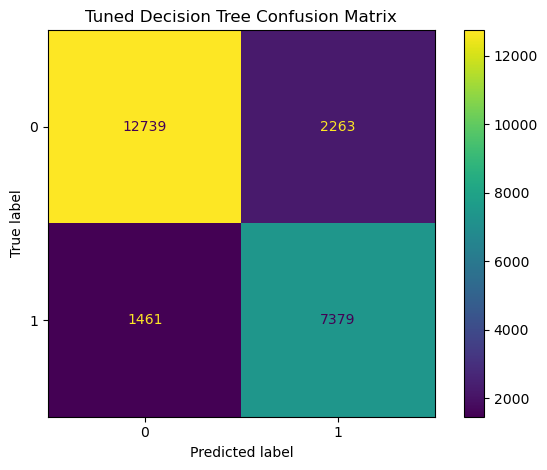

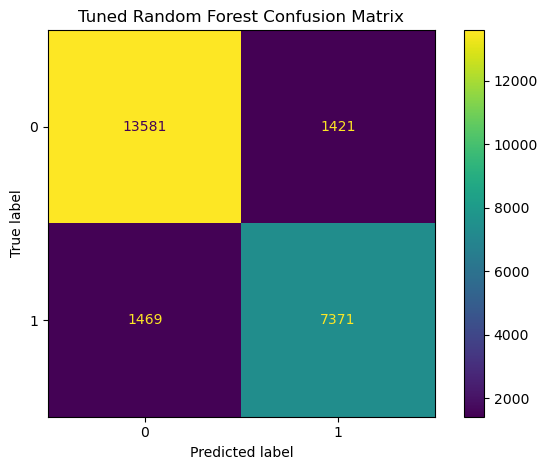

In [19]:
models_to_plot = {
    "Tuned Decision Tree": dt_search.best_estimator_,
    "Tuned Random Forest": rf_search.best_estimator_
}

for model_name, model in models_to_plot.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()

    file_name = model_name.lower().replace(" ", "_") + "_confusion_matrix.png"
    plt.savefig(IMAGE_DIR / file_name)
    plt.show()

### ROC curves ###

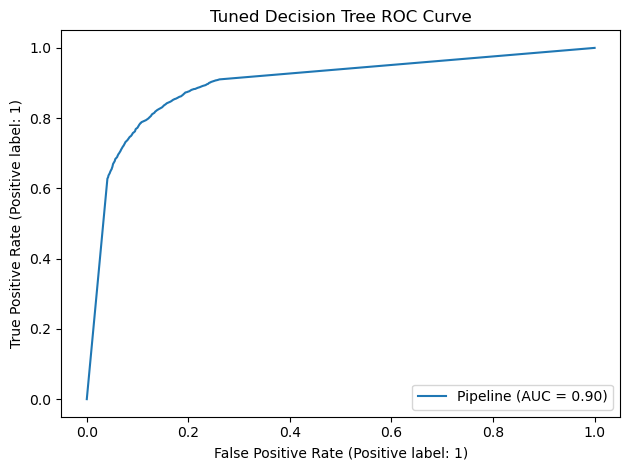

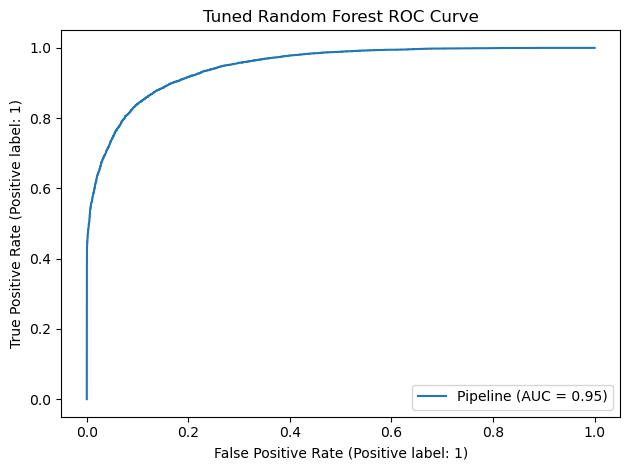

In [20]:
for model_name, model in models_to_plot.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{model_name} ROC Curve")
    plt.tight_layout()

    file_name = model_name.lower().replace(" ", "_") + "_roc_curve.png"
    plt.savefig(IMAGE_DIR / file_name)
    plt.show()

In [21]:
if rf_search.best_score_ >= dt_search.best_score_:
    best_model_name = "Random Forest"
    best_model = rf_search.best_estimator_
else:
    best_model_name = "Decision Tree"
    best_model = dt_search.best_estimator_

print("Best model selected:", best_model_name)

Best model selected: Random Forest


### Feature importance using permutation importance ###

In [22]:
importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring='f1',
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean' : importance.importances_mean,
    'importance_std' : importance.importances_std

}).sort_values(by='importance_mean', ascending=False)
(importance_df.head(10))

,feature,importance_mean,importance_std
12,country,0.098306,0.002451
13,market_segment,0.091385,0.002057
19,assigned_room_type,0.082999,0.000532
18,reserved_room_type,0.061777,0.002400
26,total_of_special_requests,0.060209,0.001373
23,customer_type,0.049148,0.001137
1,lead_time,0.044894,0.001565
21,deposit_type,0.038434,0.001584
14,distribution_channel,0.026967,0.001258
24,adr,0.025665,0.002456


In [23]:
importance_df.to_csv(REPORT_DIR / "feature_importance.csv", index=False)

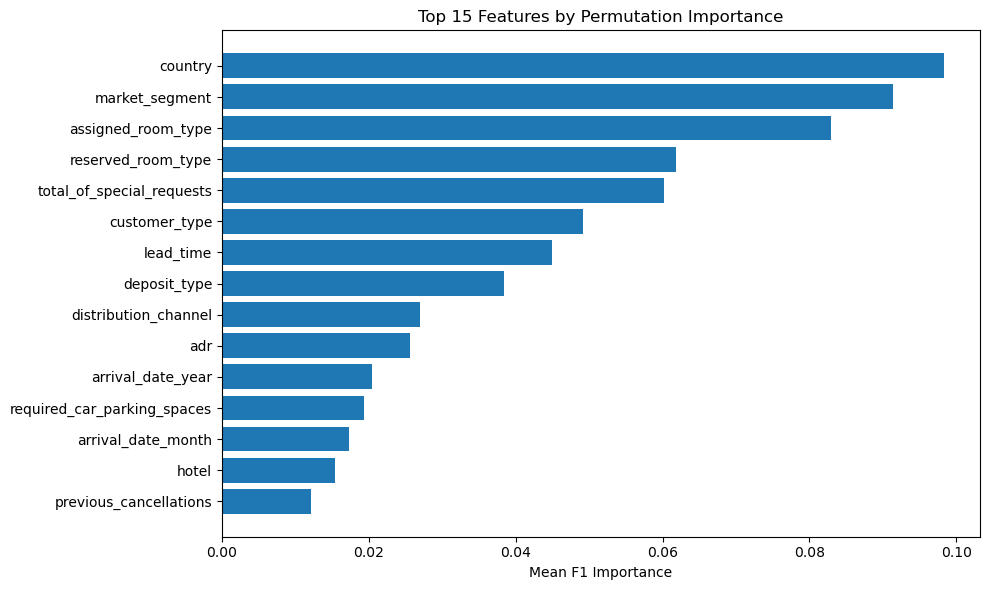

In [24]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance_mean"])
plt.gca().invert_yaxis()
plt.title("Top 15 Features by Permutation Importance")
plt.xlabel("Mean F1 Importance")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "feature_importance.png")
plt.show()

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellations',
                                                   'prev...
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type'])])),
                ('model',
                 RandomForestClassifier(bootstrap=False,
                                        class_weight='balanced',
                                        criterion='log_loss', max_depth=30,
                                        max_features='log2',
                                        min_samples_split=10, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

### Save best model ###

In [26]:
model_path = MODEL_DIR / 'best_model.joblib'
joblib.dump(best_model, model_path)
print("Best model saved to:", model_path)

Best model saved to: c:\Users\M.SRIMANREDDY\OneDrive\Desktop\DT+RF\models\best_model.joblib


### Testing saved model ###

In [27]:
loaded_model = joblib.load(model_path)

sample = X_test.iloc[[0]]
sample_prediction = loaded_model.predict(sample)[0]
sample_probability = loaded_model.predict_proba(sample)[0][1]

print("Prediction:", sample_prediction)
print("Cancellation probability:", round(sample_probability, 4))

Prediction: 0
Cancellation probability: 0.4995


In [29]:
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellations',
                                                   'prev...
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type'])])),
                ('model',
                 RandomForestClassifier(bootstrap=False,
                                        class_weight='balanced',
                                        criterion='log_loss', max_depth=30,
                                        max_features='log2',
                                        min_samples_split=10, n_estimators=300,
                                        n_jobs=-1, random_state=42))])